# Here two vector databases are created

One using the fine tuned BERT with cls pooling

One using the pretrained BERT with cls pooling

In [27]:
# Imports

from lxml import etree

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document

from sentence_transformers import SentenceTransformer, models
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import Annoy, FAISS
from typing import List
from langchain.vectorstores.base import VectorStore


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from langchain.llms import GPT4All
from langchain.chains import RetrievalQA

Parse tax law

In [28]:
import xml.etree.ElementTree as ET

def parse_xml_file(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()

    current_part = ""
    current_section = ""
    results = []

    for norm in root.findall(".//norm"):
        # Check for Part or Section in this norm
        gliederungseinheit = norm.find(".//gliederungseinheit")
        if gliederungseinheit is not None:
            kennzahl = gliederungseinheit.findtext("gliederungskennzahl")
            bez = gliederungseinheit.findtext("gliederungsbez")
            titel = gliederungseinheit.findtext("gliederungstitel")
            if kennzahl and len(kennzahl) == 3:
                current_part = f"{bez} - {titel}"
            elif kennzahl and len(kennzahl) == 6:
                current_section = f"{bez} - {titel}"

        # Subsection title
        subsection = norm.findtext(".//titel[@format='XML']")

        # Content paragraph
        for p in norm.findall(".//textdaten/text/Content/P"):
            content_text = ''.join(p.itertext()).strip()

            if content_text:
                results.append({
                    "metadata": {
                        "subtitle": current_part,
                        "section": current_section,
                        "subsection": subsection
                    },
                    "content": content_text,
                })

    return results

xml_file = "/storage/Tax_Law_RAG/german-tax-law/EStG.xml"
data_dict = parse_xml_file(xml_file)
data_dict

[{'metadata': {'subtitle': 'I. - Steuerpflicht',
   'section': '',
   'subsection': 'Steuerpflicht'},
  'content': '(1) 1Natürliche Personen, die im Inland einen Wohnsitz oder ihren gewöhnlichen Aufenthalt haben, sind unbeschränkt einkommensteuerpflichtig. 2Zum Inland im Sinne dieses Gesetzes gehört auch der der Bundesrepublik Deutschland zustehende Anteil 1.an der ausschließlichen Wirtschaftszone, soweit dort a)die lebenden und nicht lebenden natürlichen Ressourcen der Gewässer über dem Meeresboden, des Meeresbodens und seines Untergrunds erforscht, ausgebeutet, erhalten oder bewirtschaftet werden,b)andere Tätigkeiten zur wirtschaftlichen Erforschung oder Ausbeutung der ausschließlichen Wirtschaftszone ausgeübt werden, wie beispielsweise die Energieerzeugung aus Wasser, Strömung und Wind oderc)künstliche Inseln errichtet oder genutzt werden und Anlagen und Bauwerke für die in den Buchstaben a und b genannten Zwecke errichtet oder genutzt werden, und2.am Festlandsockel, soweit dort a)d

Ingest & chunk data

In [29]:
# Wrap in LangChain Document objects
documents = [
    Document(page_content=d["content"], metadata=d["metadata"])
    for d in data_dict
]

# Split each document into smaller chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=64)
chunked_docs = text_splitter.split_documents(documents)

Embed and Store 

from transformers import BertModel
import torch

model = BertModel.from_pretrained("bert-base-german-cased")
model.load_state_dict(torch.load("/storage/Tax_Law_RAG/german-tax-law/output/bert-subtitle-model-german.pt"), strict=False)
model.save_pretrained("/storage/Tax_Law_RAG/german-tax-law/your-ft-model")



from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-german-cased")
tokenizer.save_pretrained("/storage/Tax_Law_RAG/german-tax-law/your-ft-model")

Create SentenceTransformer model

from sentence_transformers import SentenceTransformer, models

bert_model_path = "/storage/Tax_Law_RAG/german-tax-law/your-ft-model"

word_embedding_model = models.Transformer(bert_model_path)

pooling_model = models.Pooling(
    word_embedding_dimension=word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_cls_token=True,
    pooling_mode_mean_tokens=False,
    pooling_mode_max_tokens=False,
)

sentence_transformer_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

sentence_transformer_model.save("/storage/Tax_Law_RAG/german-tax-law/bert-embedding-model")


In [30]:
# Init the embedding model -- fine tuned 
ft_embedding_model = HuggingFaceEmbeddings(model_name="/storage/Tax_Law_RAG/german-tax-law/output/sentence-transformer-format")

# BERT BASE
bert = models.Transformer("bert-base-german-cased")

pooling = models.Pooling(
    word_embedding_dimension=bert.get_word_embedding_dimension(),
    pooling_mode_cls_token=True,
    pooling_mode_mean_tokens=False,
    pooling_mode_max_tokens=False,
)

cls_model = SentenceTransformer(modules=[bert, pooling])
cls_model.save("custom-bert-cls")

pt_embedding_model = HuggingFaceEmbeddings(model_name="./custom-bert-cls")

FT Vector Store

In [31]:
# Create Annoy vector store from chunked docs
ft_vector_store = Annoy.from_documents(chunked_docs, ft_embedding_model)
ft_vector_store.save_local("ft_annoy_tax_code_index")

KeyboardInterrupt: 

In [ ]:
# Create FAISS vector store
ft_vector_store_2 = FAISS.from_documents(chunked_docs, ft_embedding_model)
ft_vector_store_2.save_local("faiss_ft_store")

PT Vector Store

In [ ]:
# Create Annoy vector store from chunked docs
pt_vector_store = Annoy.from_documents(chunked_docs, pt_embedding_model)
pt_vector_store.save_local("pt_annoy_tax_code_index")

In [ ]:
# Create FAISS vector store
pt_vector_store_2 = FAISS.from_documents(chunked_docs, pt_embedding_model)
pt_vector_store_2.save_local("faiss_pt_store")

Qualitative Comparison of Vector Stores

In [ ]:
def inspect_query_results(
    query: str,
    vector_stores: List[VectorStore],
    labels: List[str],
    k: int = 5,
    metadata_key: str = "subtitle",
    print_content_preview_chars: int = 200,
):
    """
    Inspect the top-k results of a query across multiple vector stores.

    Args:
        query (str): The input query string.
        vector_stores (List[VectorStore]): List of LangChain vector store objects.
        labels (List[str]): List of string labels for each vector store (e.g. "FT BERT + Annoy").
        k (int): Number of top documents to retrieve per vector store.
        metadata_key (str): Key in metadata to show (e.g., "subtitle").
        print_content_preview_chars (int): Number of characters from page content to preview.

    Returns:
        None
    """
    print(f"\n🔍 Query: \"{query}\"")
    print("-" * 80)

    for store, label in zip(vector_stores, labels):
        print(f"\n📘 {label}")
        print("=" * len(label))
        try:
            results = store.similarity_search(query, k=k)
        except:
            results = store.similarity_search_with_score(query, k=k)
            results = [res[0] for res in results]  # Strip scores if needed

        for idx, doc in enumerate(results):
            subtitle = doc.metadata.get(metadata_key, "Unknown")
            content_preview = doc.page_content[:print_content_preview_chars].replace("\n", " ")
            print(f"{idx+1}. [{subtitle}] {content_preview}...")

        print("-" * 80)

In [ ]:
vector_stores = [ft_vector_store, pt_vector_store, ft_vector_store_2, pt_vector_store_2]
labels = [
    "FT BERT + Annoy",
    "CLS BERT + Annoy",
    "FT BERT + FAISS",
    "CLS BERT + FAISS"
]
queries = [
    "Gewinn ist der Unterschiedsbetrag zwischen dem Betriebsvermögen am Schluss des Wirtschaftsjahres und dem Betriebsvermögen am Schluss des vorangegangenen Wirtschaftsjahres",  # Directly copied text from document
    "Auf Antrag des Leistenden hat das für ihn zuständige Finanzamt, wenn der zu sichernde Steueranspruch nicht gefährdet erscheint und ein inländischer Empfangsbevollmächtigter bestellt ist, eine Bescheinigung nach amtlich vorgeschriebenem Vordruck zu erteilen, die den Leistungsempfänger von der Pflicht zum Steuerabzug befreit.",  # Direct quoting
    "Die Regelungen dieses Gesetzes zu Ehegatten und Ehen sind auch auf Lebenspartner und Lebenspartnerschaften anzuwenden.",  # Near text from the documents
    "Bäume umarmen ist cool!"  # A garbage query, unrelated to the tax law
]

for query in queries:
    inspect_query_results(
        query=query,
        vector_stores=vector_stores,
        labels=labels,
        k=5,
        metadata_key="subtitle"
    )



🔍 Query: "Gewinn ist der Unterschiedsbetrag zwischen dem Betriebsvermögen am Schluss des Wirtschaftsjahres und dem Betriebsvermögen am Schluss des vorangegangenen Wirtschaftsjahres"
--------------------------------------------------------------------------------

📘 FT BERT + Annoy
1. [II. - Einkommen] (1) 1Gewinn ist der Unterschiedsbetrag zwischen dem Betriebsvermögen am Schluss des Wirtschaftsjahres und dem Betriebsvermögen am Schluss des vorangegangenen Wirtschaftsjahres, vermehrt um den Wert de...
2. [II. - Einkommen] (4) 1Eine Pensionsrückstellung darf in einem Wirtschaftsjahr höchstens um den Unterschied zwischen dem Teilwert der Pensionsverpflichtung am Schluss des Wirtschaftsjahres und am Schluss des vorangegan...
3. [II. - Einkommen] (2) 1Soweit der Verlust nach den Absätzen 1 und 1a nicht ausgeglichen oder abgezogen werden darf, mindert er die Gewinne, die dem Kommanditisten in späteren Wirtschaftsjahren aus seiner Beteiligung an...
4. [II. - Einkommen] anzuwenden, dass der 

Comparison of Embedding Models' Embedding Spaces (Low dimensional projection)

In [ ]:
import matplotlib.patches as mpatches

def plot_two_faiss_embeddings_pca_side_by_side(
    vector_store1: FAISS,
    vector_store2: FAISS,
    color_key="subtitle",
    title1="Vector Store 1",
    title2="Vector Store 2",
    figsize=(16, 7),
):
    """
    Plot PCA projections of embeddings from two LangChain FAISS vector stores side by side.

    Args:
        vector_store1 (FAISS): First FAISS vector store.
        vector_store2 (FAISS): Second FAISS vector store.
        color_key (str): Metadata key to color points by. Default is "subtitle".
        title1 (str): Title for the first subplot.
        title2 (str): Title for the second subplot.
        figsize (tuple): Figure size.

    Returns:
        fig (matplotlib.figure.Figure): The matplotlib figure object.
        axs (np.ndarray): Array of the two subplot axes.
    """
    def extract_embeddings_and_labels(vector_store):
        faiss_index = vector_store.index
        num_vectors = faiss_index.ntotal
        dim = faiss_index.d
        embeddings = np.zeros((num_vectors, dim), dtype="float32")
        faiss_index.reconstruct_n(0, num_vectors, embeddings)
        metadatas = [doc.metadata for doc in vector_store.docstore._dict.values()]
        labels = [meta.get(color_key, "Unknown") for meta in metadatas]
        return embeddings, labels

    embeddings1, labels1 = extract_embeddings_and_labels(vector_store1)
    embeddings2, labels2 = extract_embeddings_and_labels(vector_store2)

    # Combine unique labels from both sets for consistent coloring
    unique_labels = sorted(set(labels1) | set(labels2))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

    color_indices1 = [label_to_idx[label] for label in labels1]
    color_indices2 = [label_to_idx[label] for label in labels2]

    pca = PCA(n_components=2)
    # Fit PCA on combined data for consistent axes
    combined_embeddings = np.vstack([embeddings1, embeddings2])
    combined_projected = pca.fit_transform(combined_embeddings)

    projected1 = combined_projected[:len(embeddings1)]
    projected2 = combined_projected[len(embeddings1):]

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    scatter1 = axs[0].scatter(projected1[:, 0], projected1[:, 1], c=color_indices1, cmap="tab20", alpha=0.7, s=5)
    scatter2 = axs[1].scatter(projected2[:, 0], projected2[:, 1], c=color_indices2, cmap="tab20", alpha=0.7, s=5)

    # Legend (one common legend on the right)
    handles, labels = scatter1.legend_elements()
    cmap = plt.get_cmap("tab20")  
    handles = [mpatches.Patch(color=cmap(label_to_idx[label] % 20), label=label) for label in unique_labels]

    fig.legend(handles, unique_labels, title=color_key, loc='center right')

    axs[0].set_title(title1)
    axs[1].set_title(title2)

    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100

    for ax in axs:
        ax.set_xlabel(f"PC1 ({var_pc1:.1f}%)")
        ax.set_ylabel(f"PC2 ({var_pc2:.1f}%)")

    plt.tight_layout(rect=[0, 0, 0.60, 1])  # Leave room for legend on right
    #plt.subplots_adjust(right=0.75)

    return fig, axs


PCA

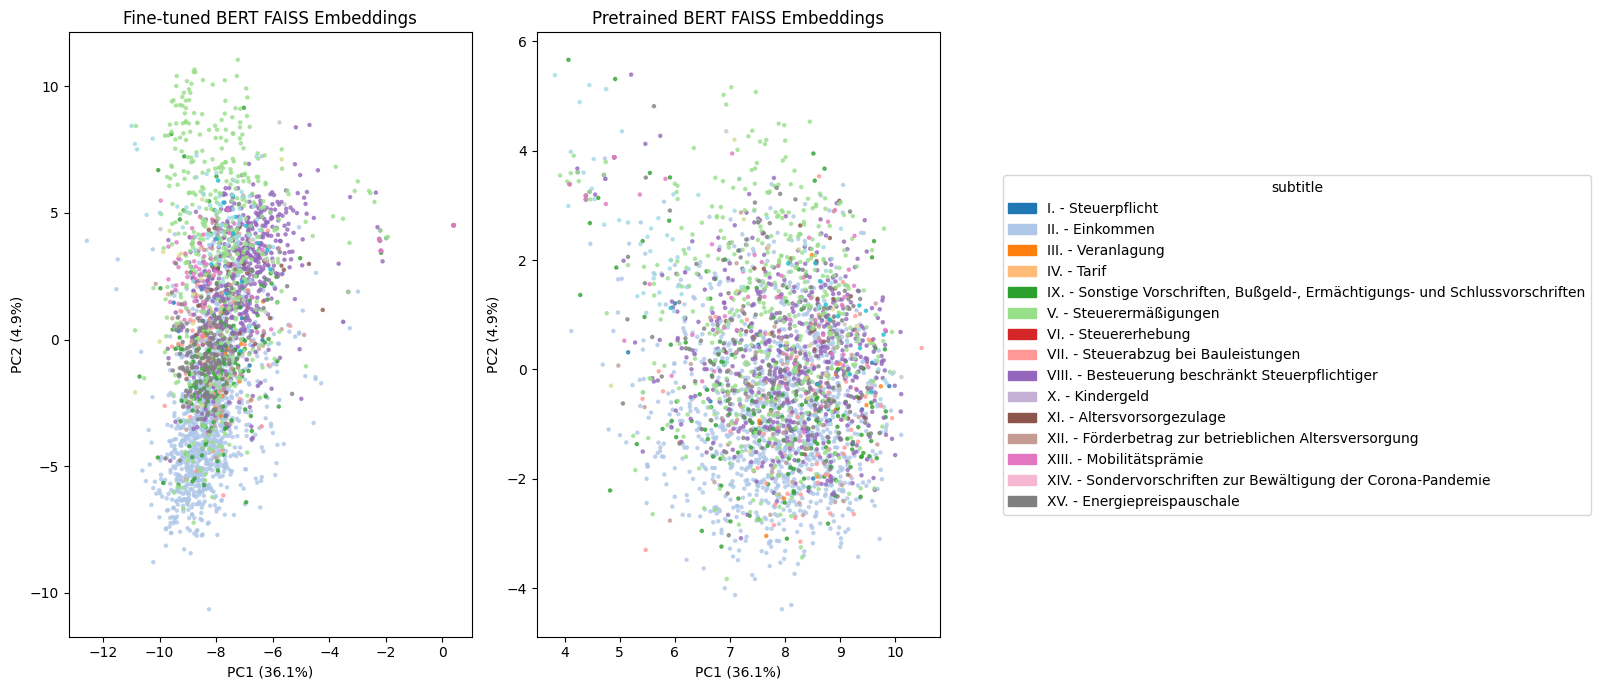

In [ ]:
fig, axs = plot_two_faiss_embeddings_pca_side_by_side(
    ft_vector_store_2,
    pt_vector_store_2,
    color_key="subtitle",
    title1="Fine-tuned BERT FAISS Embeddings",
    title2="Pretrained BERT FAISS Embeddings"
)
plt.show()


In [ ]:
from collections import Counter

def count_labels_in_faiss_store(vector_store, color_key="subtitle"):
    metadatas = [doc.metadata for doc in vector_store.docstore._dict.values()]
    labels = [meta.get(color_key, "Unknown") for meta in metadatas]
    return Counter(labels)

# Counts für beide Stores ausgeben
ft_counts = count_labels_in_faiss_store(ft_vector_store_2)
pt_counts = count_labels_in_faiss_store(pt_vector_store_2)

print("📊 Label counts in ft_vector_store_2:")
for label, count in sorted(ft_counts.items()):
    print(f"{label}: {count}")

print("\n📊 Label counts in pt_vector_store_2:")
for label, count in sorted(pt_counts.items()):
    print(f"{label}: {count}")


📊 Label counts in ft_vector_store_2:
I. - Steuerpflicht: 16
II. - Einkommen: 1136
III. - Veranlagung: 16
IV. - Tarif: 179
IX. - Sonstige Vorschriften, Bußgeld-, Ermächtigungs- und Schlussvorschriften: 469
V. - Steuerermäßigungen: 68
VI. - Steuererhebung: 551
VII. - Steuerabzug bei Bauleistungen: 27
VIII. - Besteuerung beschränkt Steuerpflichtiger: 76
X. - Kindergeld: 67
XI. - Altersvorsorgezulage: 170
XII. - Förderbetrag zur betrieblichen Altersversorgung: 11
XIII. - Mobilitätsprämie: 15
XIV. - Sondervorschriften zur Bewältigung der Corona-Pandemie: 14
XV. - Energiepreispauschale: 69

📊 Label counts in pt_vector_store_2:
I. - Steuerpflicht: 16
II. - Einkommen: 1136
III. - Veranlagung: 16
IV. - Tarif: 179
IX. - Sonstige Vorschriften, Bußgeld-, Ermächtigungs- und Schlussvorschriften: 469
V. - Steuerermäßigungen: 68
VI. - Steuererhebung: 551
VII. - Steuerabzug bei Bauleistungen: 27
VIII. - Besteuerung beschränkt Steuerpflichtiger: 76
X. - Kindergeld: 67
XI. - Altersvorsorgezulage: 170
XII

### Analysis of PC1-PC2 Embedding Space

One can see clearer grouping by subtitle in the Fine Tuned BERT's embedding space. This is presumably due to the similarity in the embedded representation induced by the document classification fine tuning task. Especially subtitles 2, 5 and 8 seem to be more clearly separated.